In [32]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve

In [33]:
df = pd.read_csv('../data/cleaned_data.csv')
print(df.shape)
df.head() 

(2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [34]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])
df.head()
print(le.classes_) #this prints the crop in the order in which it was encoded, so like rice-20 apple-0 etc.

['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [35]:
def classification_metrics(y_actual, y_pred):
    acc = round(accuracy_score(y_actual, y_pred)*100, 2)
    precision = round(precision_score(y_actual, y_pred, average='weighted') * 100, 2) #weighted because we have multiple classes
    recall = round(recall_score(y_actual, y_pred, average='weighted')*100, 2)
    f1 = round(f1_score(y_actual, y_pred, average='weighted')*100, 2)
    confusionmatrix = confusion_matrix(y_actual,y_pred)
    return {"Accuracy":acc, "Precision":precision, "Recall":recall, "F1":f1, "Confusion matrix":confusionmatrix.tolist()} #tolist()because i did not want the confusion matrix to be a numpy array and to have the data type

In [36]:
X = df.drop('label', axis=1)
y = df['label']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:

#hyperparameter tuning in order to find the best parameters for our random forest model, we will be using grid search cross validation to find the best parameters for our random forest model. 
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='f1_weighted')

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


CV F1 Score: 0.9936140141286598


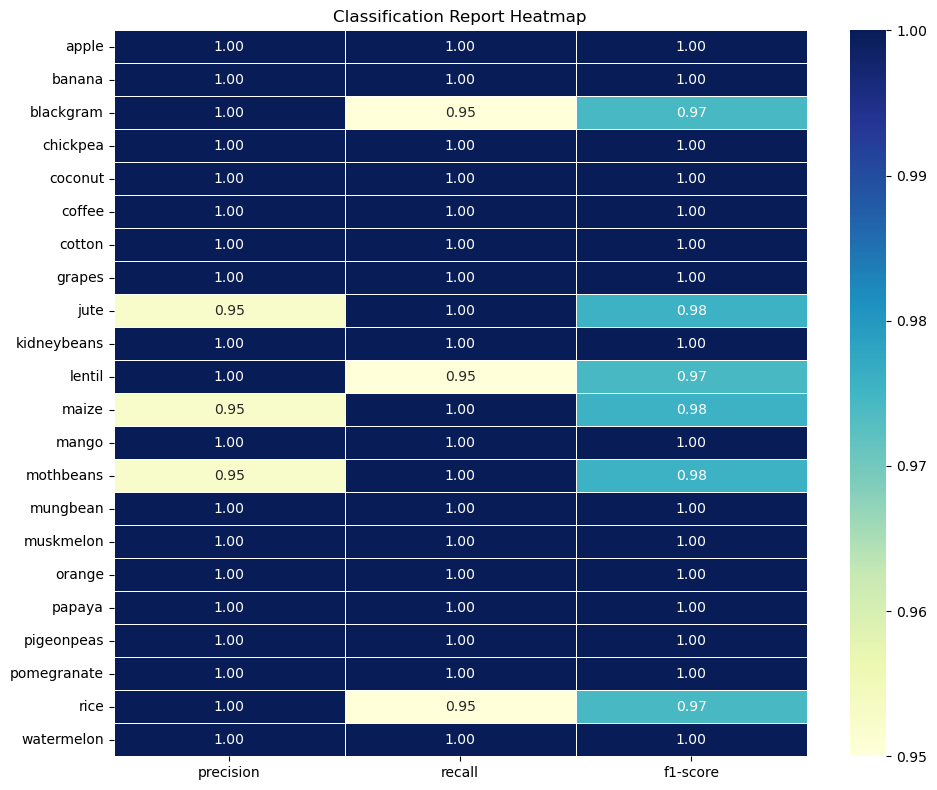

In [39]:
#evaluating the best model
rf = grid.best_estimator_
y_pred = rf.predict(X_test)
classification_metrics(y_test, y_pred)

scores = cross_val_score(rf, X, y, cv=5, scoring='f1_weighted')
print("CV F1 Score:", scores.mean())

report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# drop the averages rows if you want only per-class metrics
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'])

plt.figure(figsize=(10, 8))
sns.heatmap(
    report_df[['precision', 'recall', 'f1-score']],  # drop support column
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5
)
plt.title("Classification Report Heatmap")
plt.tight_layout()
plt.show()

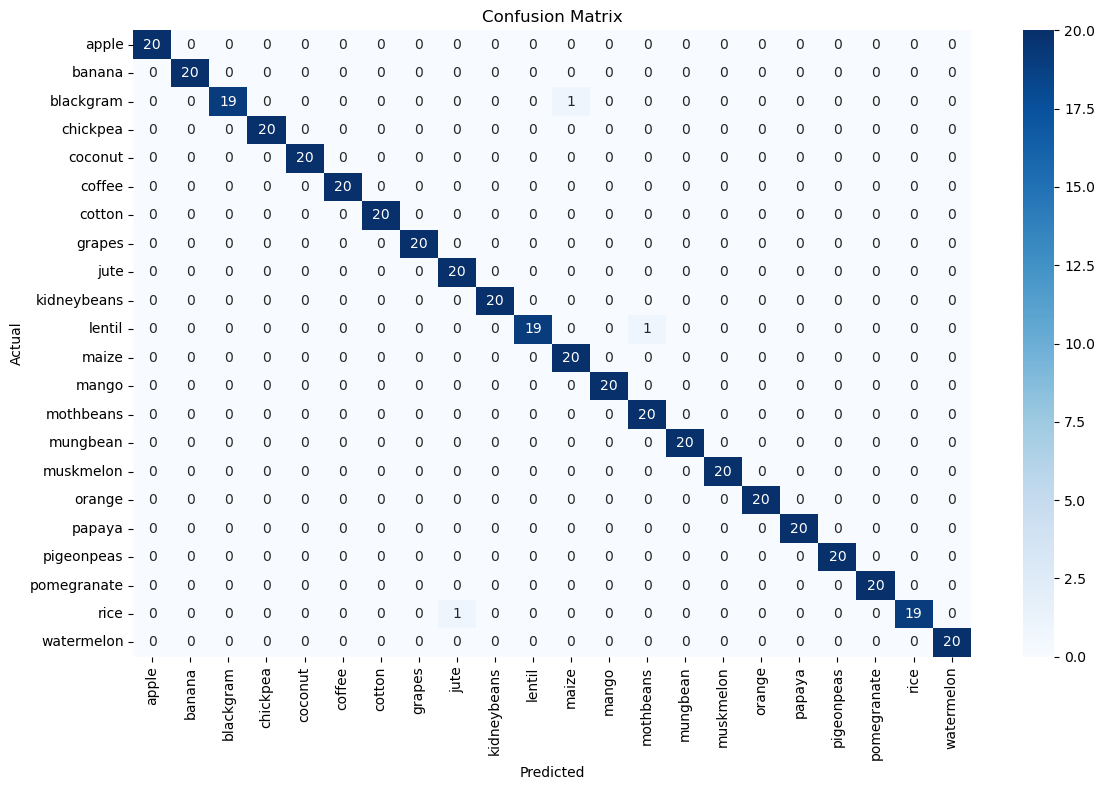

In [40]:
#virtualization of the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [41]:
#using OOB to train
rf_oob = RandomForestClassifier(**grid.best_params_, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)
print("OOB Score:", round(rf_oob.oob_score_ * 100, 2))

OOB Score: 99.38


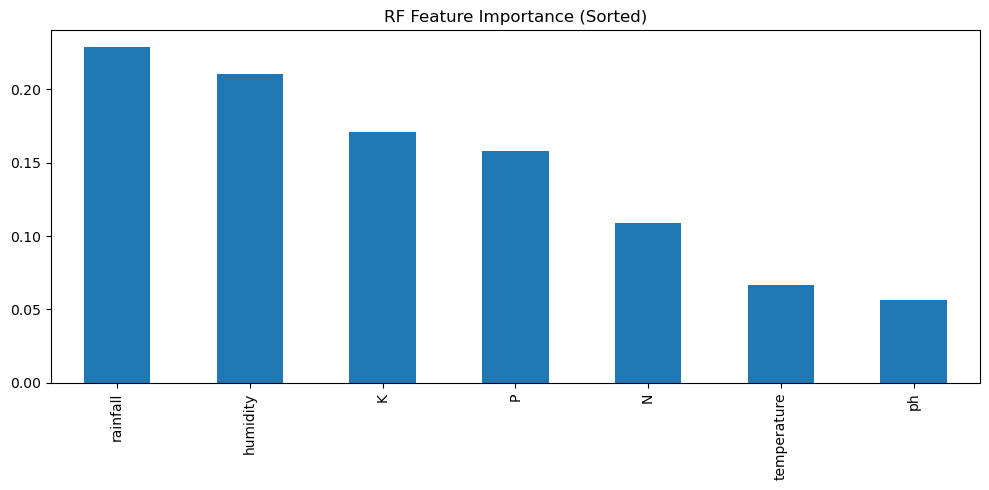

In [42]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
importances.plot(kind='bar')
plt.title("RF Feature Importance (Sorted)")
plt.tight_layout()
plt.show()

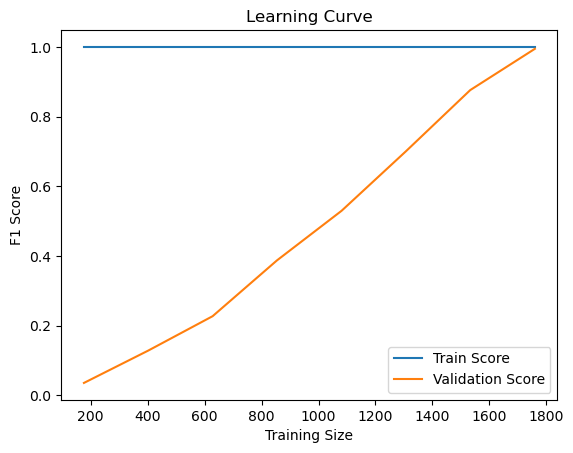

In [43]:
#learning curves


train_sizes, train_scores, val_scores = learning_curve(
    rf, X, y, cv=5, scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 8)
)

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train Score')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation Score')
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve")
plt.legend()
plt.show()